In [5]:
import pandas as pd

df=pd.read_csv(r"C:\Users\Vishal Tiwari\OneDrive\Desktop\crop-price-predicition\data\crop_price_dataset.csv")
df.head()

,month,commodity_name,avg_modal_price,avg_min_price,avg_max_price,state_name,district_name,calculationType,change
0,2025-03-01,Maize,2341.58,2191.23,2402.98,India,All,Monthly,-14.43
1,2025-02-01,Maize,2356.01,2202.35,2414.46,India,All,Monthly,-26.19
2,2025-01-01,Maize,2382.20,2221.31,2448.22,India,All,Monthly,53.42
3,2024-12-01,Maize,2328.78,2164.86,2411.66,India,All,Monthly,55.32
4,2024-11-01,Maize,2273.46,2077.63,2377.78,India,All,Monthly,35.48


In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   month            2810 non-null   object 
 1   commodity_name   2810 non-null   object 
 2   avg_modal_price  2810 non-null   float64
 3   avg_min_price    2810 non-null   float64
 4   avg_max_price    2810 non-null   float64
 5   state_name       2810 non-null   object 
 6   district_name    2810 non-null   object 
 7   calculationType  2810 non-null   object 
 8   change           2794 non-null   float64
dtypes: float64(4), object(5)
memory usage: 197.7+ KB


month               0
commodity_name      0
avg_modal_price     0
avg_min_price       0
avg_max_price       0
state_name          0
district_name       0
calculationType     0
change             16
dtype: int64

In [7]:
df.fillna(method='ffill', inplace=True)
df.drop_duplicates(inplace=True)

C:\Users\Vishal Tiwari\AppData\Local\Temp\ipykernel_59896\2025903430.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [12]:
df['month']=pd.to_datetime(df['month'])
df['Year']=df['month'].dt.year
df['Month']=df['month'].dt.month

In [13]:
y=df['avg_modal_price']

In [14]:
X=df[['Year','Month','avg_min_price','avg_max_price']]

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
predictions = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))

MAE: 413.94480450516664
MSE: 1355808.4534398173


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))

MAE: 413.94480450516664
MSE: 1355808.4534398173


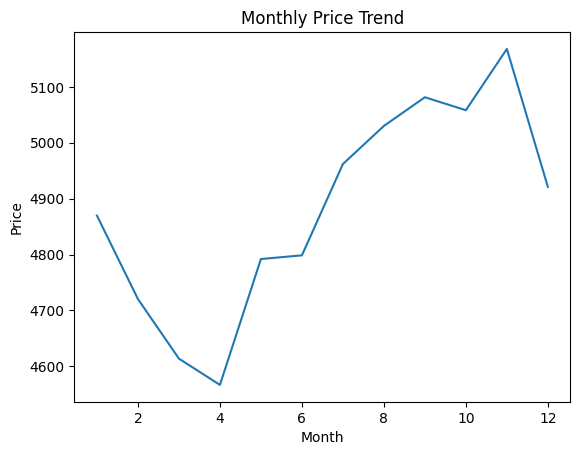

In [20]:
import matplotlib.pyplot as plt

df.groupby('Month')['avg_modal_price'].mean().plot()
plt.title("Monthly Price Trend")
plt.xlabel("Month")
plt.ylabel("Price")
plt.show()

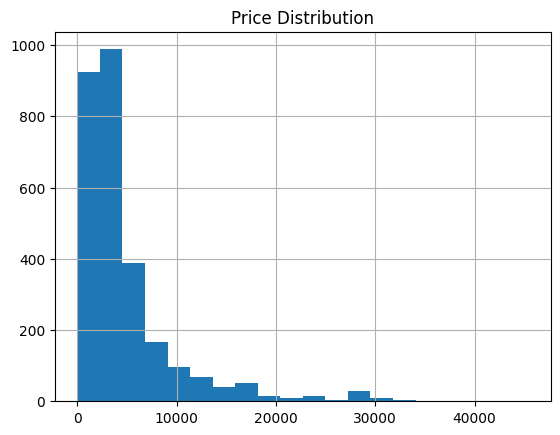

In [21]:
df['avg_modal_price'].hist(bins=20)
plt.title("Price Distribution")
plt.show()

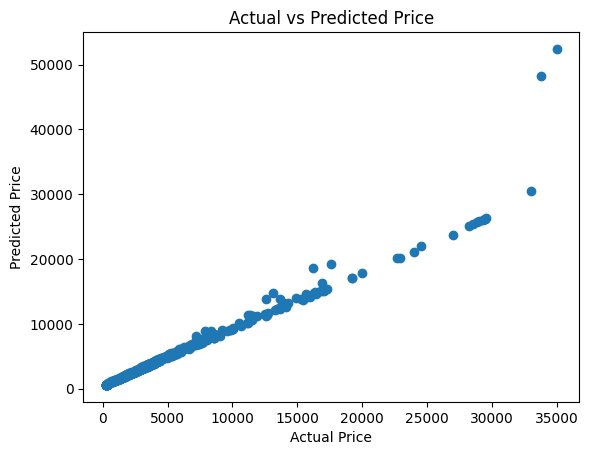

In [22]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [23]:
def suggest_action(predicted, current):
    if predicted > current:
        return "Hold the crop (Price may increase)"
    else:
        return "Sell now (Price may drop)"

In [24]:
current_price = 2200
predicted_price = model.predict([[2025, 4, 2100, 2400]])

print(suggest_action(predicted_price[0], current_price))

Hold the crop (Price may increase)


C:\Users\Vishal Tiwari\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
import pickle

pickle.dump(model, open("../models/model.pkl", "wb"))

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Year', 'Month', 'avg_min_price', 'avg_max_price']]
y = df['avg_modal_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
import pickle

with open("../models/model.pkl", "wb") as f:
    pickle.dump(model, f)

In [29]:
import os
import pickle

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
model_path = os.path.join(BASE_DIR, "models", "model.pkl")

with open(model_path, "rb") as f:
    model = pickle.load(f)

NameError: name '__file__' is not defined

In [1]:
price_df['month'] = pd.to_datetime(price_df['month'])

price_df['Year'] = price_df['month'].dt.year
price_df['Month'] = price_df['month'].dt.month

price_df.dropna(inplace=True)
price_df.drop_duplicates(inplace=True)

NameError: name 'pd' is not defined